In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    '/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv',
    sep='\t'
)

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

print("\nData Types")
print(df.dtypes)

(2240, 29)

Missing Values
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Data Types
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome

In [4]:
df['Income'] = df['Income'].fillna(
    df['Income'].median()
)

In [5]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    format='%d-%m-%Y'
)

In [6]:
df['Age'] = 2026 - df['Year_Birth']

df['Children'] = (
    df['Kidhome']
    + df['Teenhome']
)

df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

df['Total_Purchases'] = (
    df['NumWebPurchases']
    + df['NumCatalogPurchases']
    + df['NumStorePurchases']
)

df['Campaign_Success'] = (
    df['AcceptedCmp1']
    + df['AcceptedCmp2']
    + df['AcceptedCmp3']
    + df['AcceptedCmp4']
    + df['AcceptedCmp5']
)

latest_date = df['Dt_Customer'].max()

df['Customer_Tenure'] = (
    latest_date - df['Dt_Customer']
).dt.days

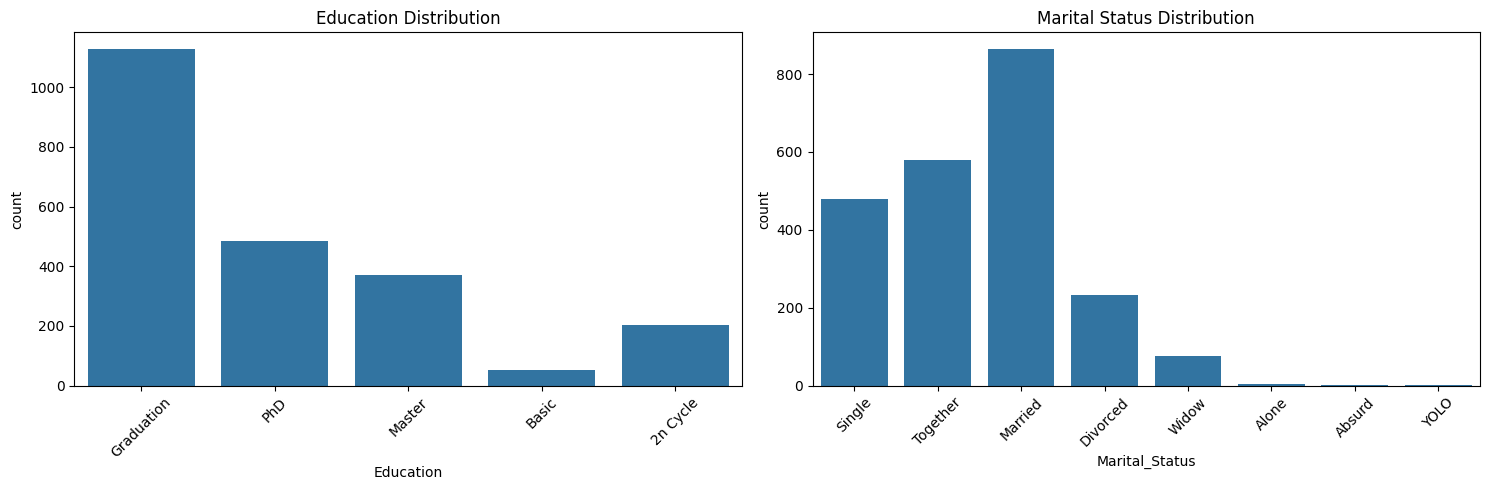

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, x='Education', ax=axes[0])
axes[0].set_title('Education Distribution')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Marital_Status', ax=axes[1])
axes[1].set_title('Marital Status Distribution')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

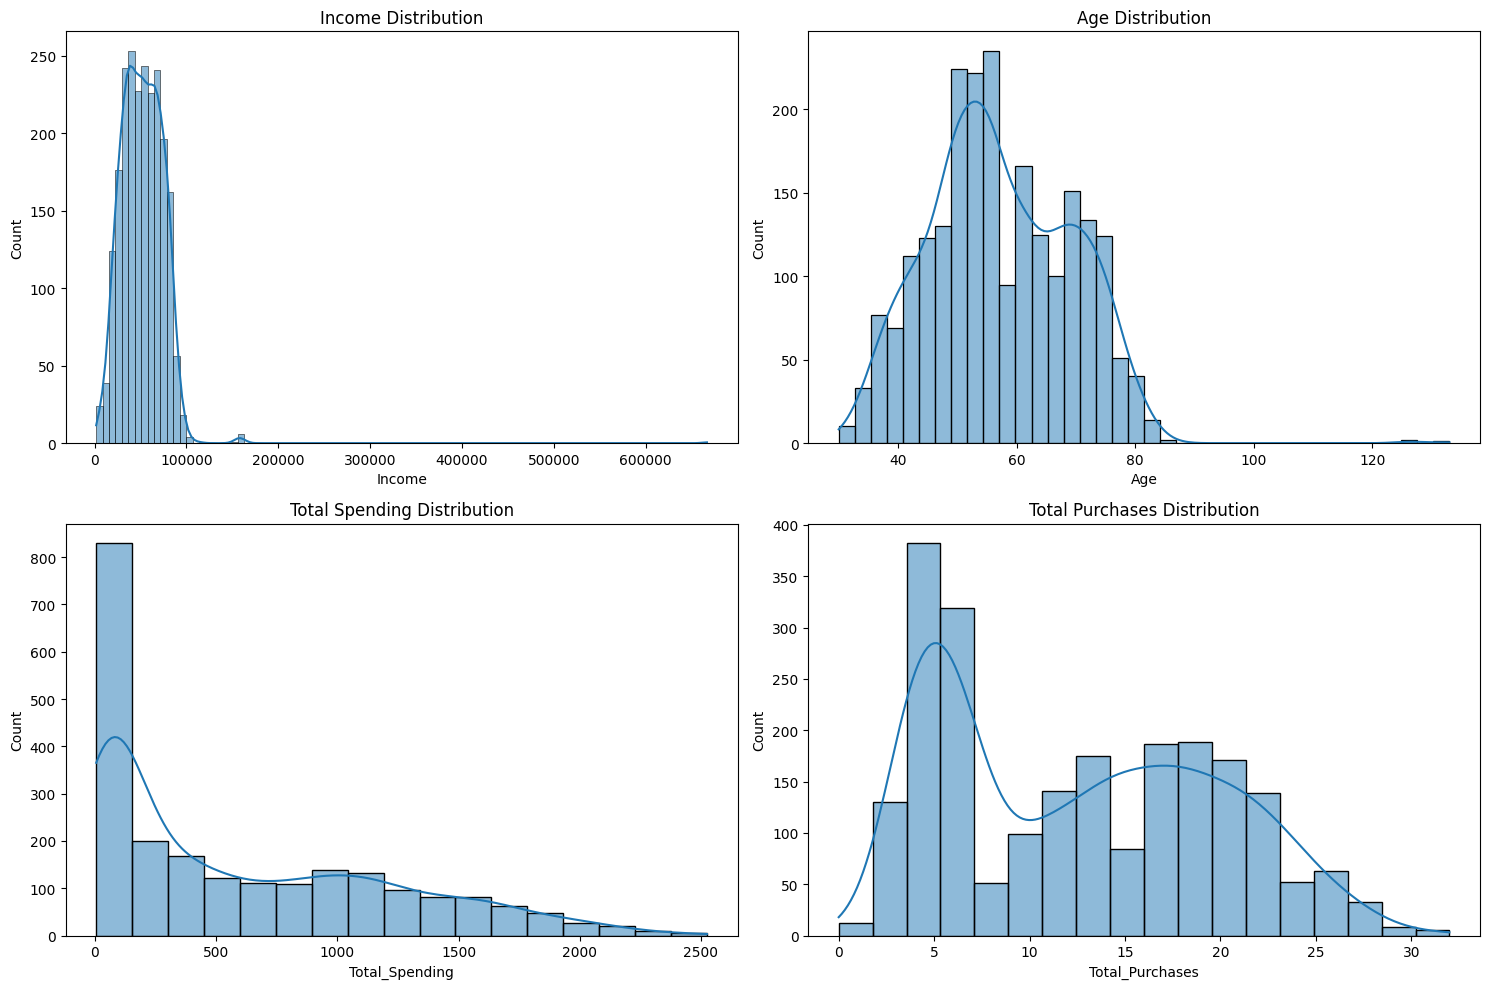

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['Income'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Income Distribution')

sns.histplot(df['Age'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

sns.histplot(df['Total_Spending'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Total Spending Distribution')

sns.histplot(df['Total_Purchases'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Total Purchases Distribution')

plt.tight_layout()
plt.show()

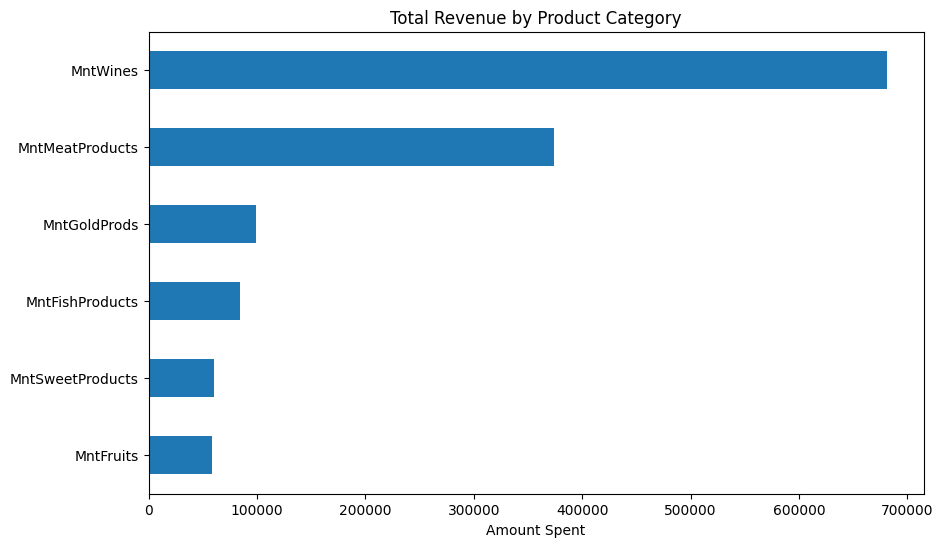

In [9]:
spending_cols = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

df[spending_cols].sum().sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Total Revenue by Product Category')
plt.xlabel('Amount Spent')
plt.show()

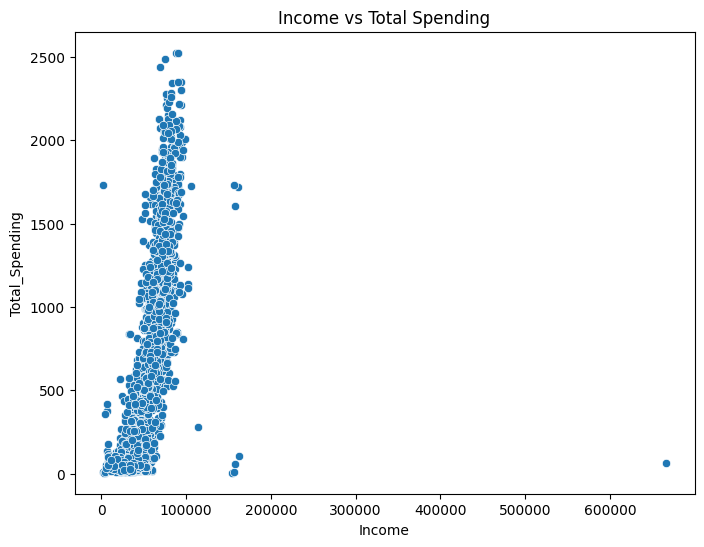

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending'
)

plt.title('Income vs Total Spending')
plt.show()

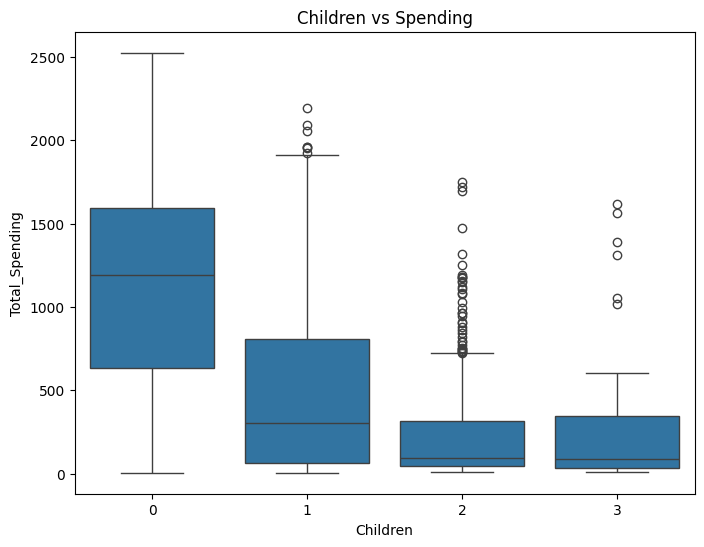

In [11]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Children',
    y='Total_Spending'
)

plt.title('Children vs Spending')
plt.show()

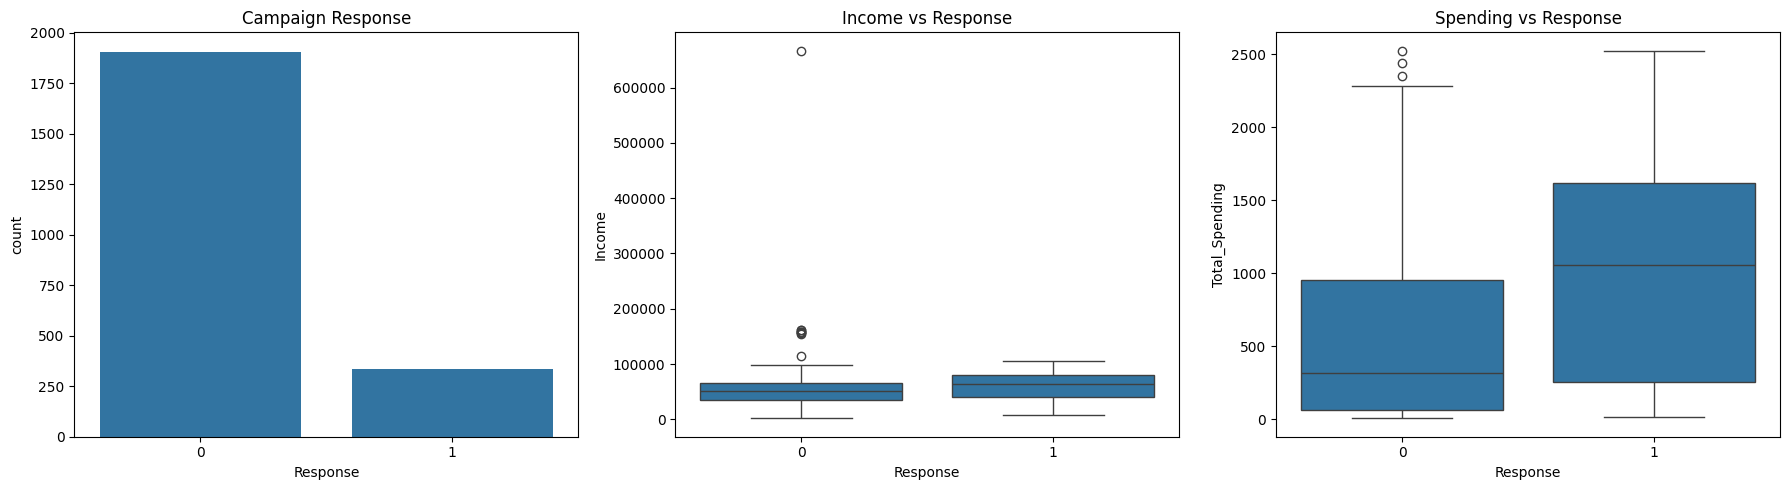

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x='Response', ax=axes[0])
axes[0].set_title('Campaign Response')

sns.boxplot(
    data=df,
    x='Response',
    y='Income',
    ax=axes[1]
)
axes[1].set_title('Income vs Response')

sns.boxplot(
    data=df,
    x='Response',
    y='Total_Spending',
    ax=axes[2]
)
axes[2].set_title('Spending vs Response')

plt.tight_layout()
plt.show()

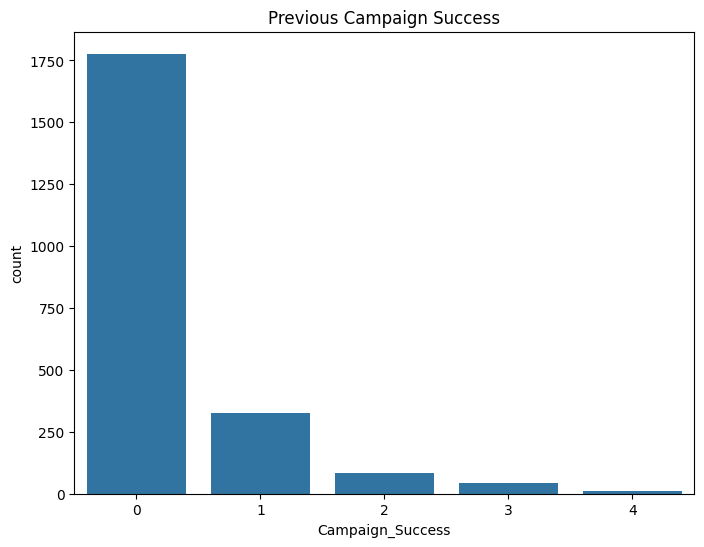

In [13]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=df,
    x='Campaign_Success'
)

plt.title('Previous Campaign Success')
plt.show()

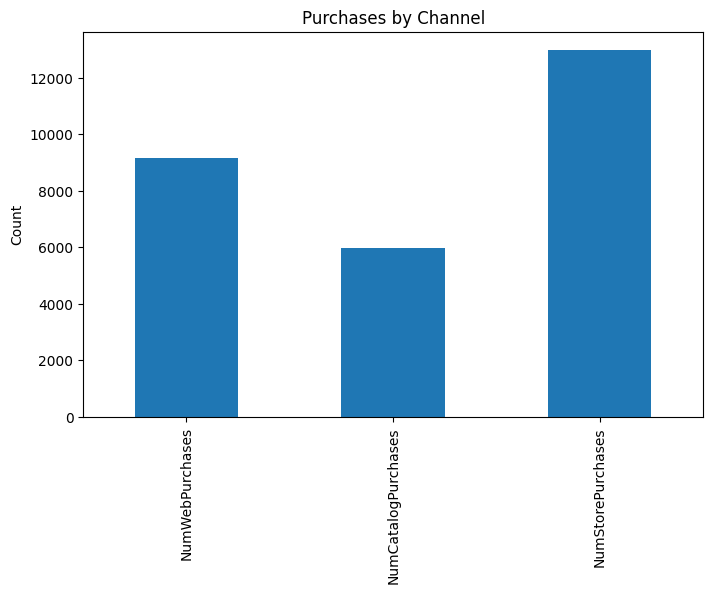

In [14]:

purchase_channels = [
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases'
]

df[purchase_channels].sum().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Purchases by Channel')
plt.ylabel('Count')
plt.show()

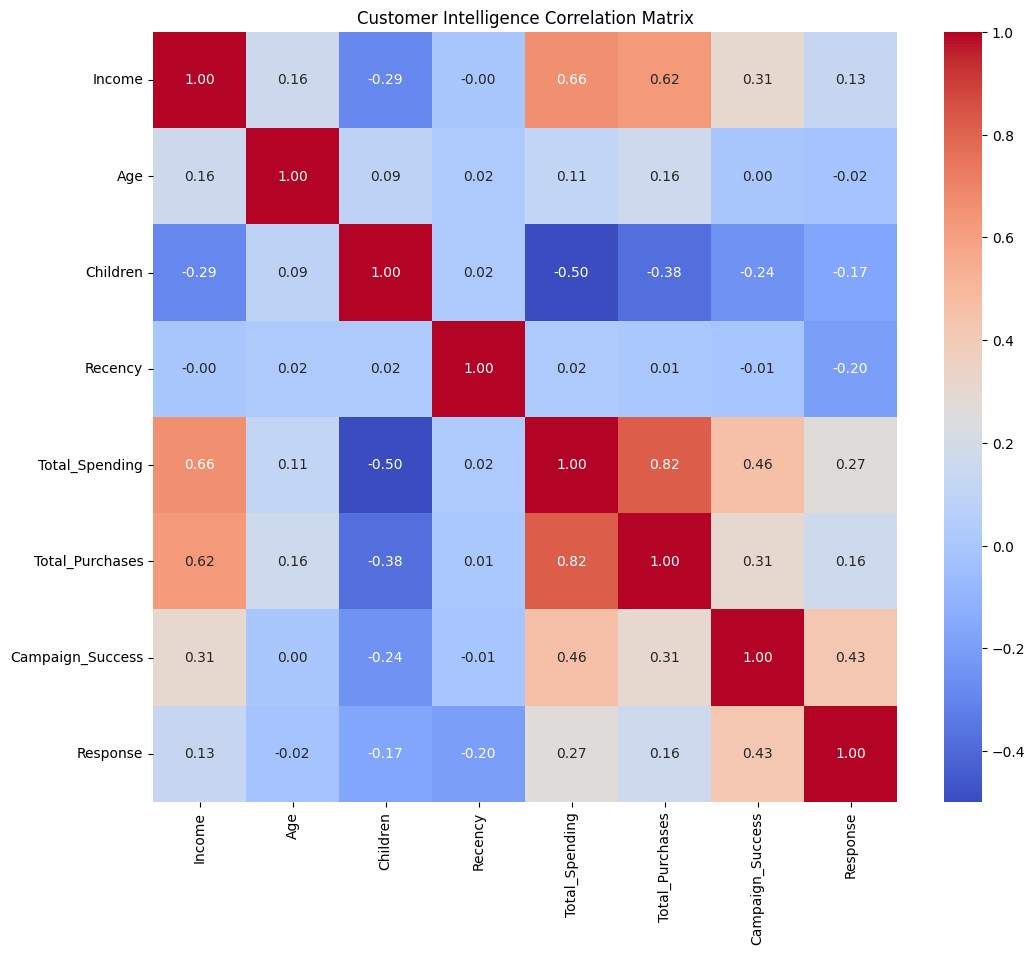

In [15]:
plt.figure(figsize=(12,10))

corr_cols = [
    'Income',
    'Age',
    'Children',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'Campaign_Success',
    'Response'
]

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Customer Intelligence Correlation Matrix')
plt.show()

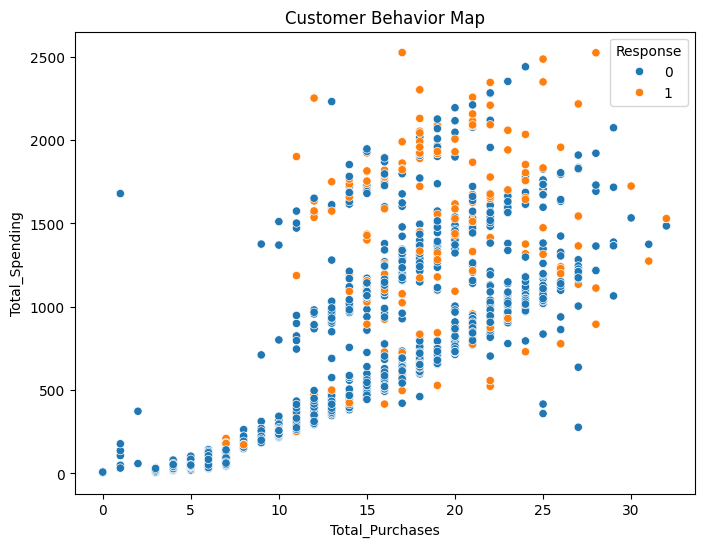

In [16]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Total_Purchases',
    y='Total_Spending',
    hue='Response'
)

plt.title('Customer Behavior Map')
plt.show()

In [17]:
df.drop(
    ['ID', 'Z_CostContact', 'Z_Revenue'],
    axis=1,
    inplace=True
)

In [18]:
y = df['Response']

X = df.drop(
    ['Response', 'Dt_Customer'],
    axis=1
)

In [19]:
ordinal_cols = ['Education']

nominal_cols = ['Marital_Status']

numeric_cols = [
    col for col in X.columns
    if col not in ordinal_cols + nominal_cols
]

print("Ordinal:", ordinal_cols)
print("Nominal:", nominal_cols)
print("Numeric:", len(numeric_cols))

Ordinal: ['Education']
Nominal: ['Marital_Status']
Numeric: 28


In [20]:
education_order = [[
    'Basic',
    '2n Cycle',
    'Graduation',
    'Master',
    'PhD'
]]

In [21]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder,
    StandardScaler
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'ordinal',
            OrdinalEncoder(
                categories=education_order
            ),
            ordinal_cols
        ),

        (
            'nominal',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            nominal_cols
        ),

        (
            'numeric',
            StandardScaler(),
            numeric_cols
        )
    ]
)

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1792, 30)
(448, 30)


In [23]:
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier',
     LogisticRegression(
         max_iter=1000
     ))
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

def evaluate_model(name, y_true, y_pred):

    results.append([
        name,
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ])

In [25]:
evaluate_model(
    'Logistic Regression',
    y_test,
    y_pred_lr
)

**knn**

In [26]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

evaluate_model(
    'KNN',
    y_test,
    y_pred_knn
)

In [27]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

evaluate_model(
    'SVM',
    y_test,
    y_pred_svm
)

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     DecisionTreeClassifier(
         random_state=42
     ))
])

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

evaluate_model(
    'Decision Tree',
    y_test,
    y_pred_dt
)

In [29]:
pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
).sort_values(
    'F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.886161,0.690476,0.432836,0.53211
3,Decision Tree,0.854911,0.517241,0.447761,0.48000
1,KNN,0.872768,0.625000,0.373134,0.46729
2,SVM,0.879464,0.709677,0.328358,0.44898


**Random Forest**

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     RandomForestClassifier(
         n_estimators=200,
         random_state=42
     ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

evaluate_model(
    'Random Forest',
    y_test,
    y_pred_rf
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     RandomForestClassifier(
         n_estimators=200,
         random_state=42
     ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

evaluate_model(
    'Random Forest',
    y_test,
    y_pred_rf
)

**Gradient Boosting**

In [32]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     GradientBoostingClassifier(
         n_estimators=200,
         random_state=42
     ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

evaluate_model(
    'Gradient Boosting',
    y_test,
    y_pred_gb
)

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     GradientBoostingClassifier(
         n_estimators=200,
         random_state=42
     ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

evaluate_model(
    'Gradient Boosting',
    y_test,
    y_pred_gb
)

In [34]:
from xgboost import XGBClassifier

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     XGBClassifier(
         n_estimators=200,
         max_depth=5,
         learning_rate=0.05,
         random_state=42
     ))
])

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

evaluate_model(
    'XGBoost',
    y_test,
    y_pred_xgb
)

In [35]:
from lightgbm import LGBMClassifier

lgbm_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     LGBMClassifier(
         n_estimators=200,
         random_state=42
     ))
])

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

evaluate_model(
    'LightGBM',
    y_test,
    y_pred_lgbm
)

[LightGBM] [Info] Number of positive: 267, number of negative: 1525
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2160
[LightGBM] [Info] Number of data points in the train set: 1792, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.148996 -> initscore=-1.742501
[LightGBM] [Info] Start training from score -1.742501


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [36]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df.sort_values(
    'F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
9,LightGBM,0.890625,0.714286,0.447761,0.550459
8,XGBoost,0.892857,0.743590,0.432836,0.547170
6,Gradient Boosting,0.895089,0.777778,0.417910,0.543689
7,Gradient Boosting,0.895089,0.777778,0.417910,0.543689
0,Logistic Regression,0.886161,0.690476,0.432836,0.532110
3,Decision Tree,0.854911,0.517241,0.447761,0.480000
5,Random Forest,0.888393,0.793103,0.343284,0.479167
4,Random Forest,0.888393,0.793103,0.343284,0.479167
1,KNN,0.872768,0.625000,0.373134,0.467290
2,SVM,0.879464,0.709677,0.328358,0.448980


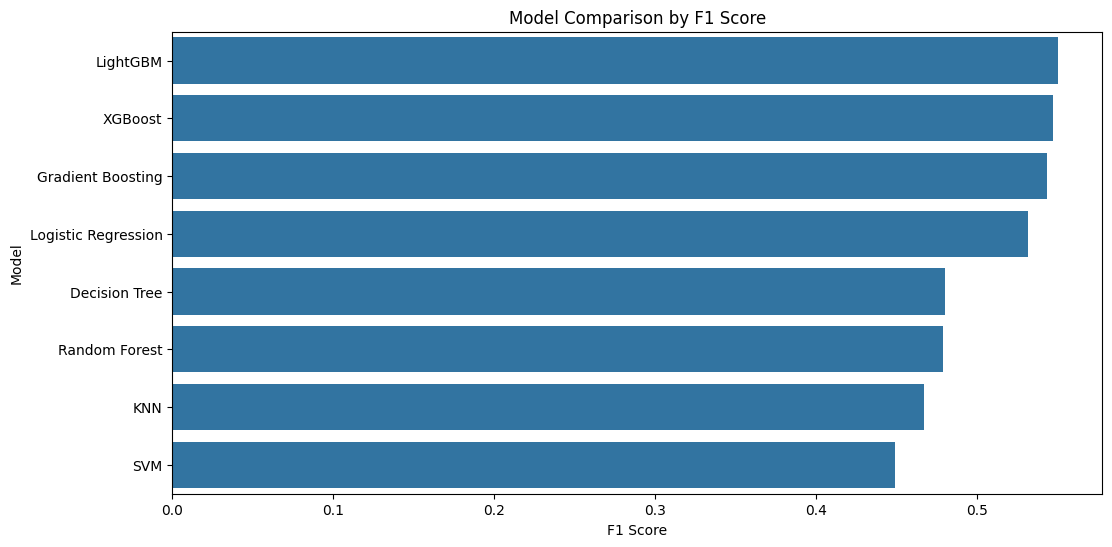

In [37]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df.sort_values(
        'F1 Score',
        ascending=False
    ),
    x='F1 Score',
    y='Model'
)

plt.title('Model Comparison by F1 Score')
plt.show()

In [38]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': lgbm_model.named_steps[
        'classifier'
    ].feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

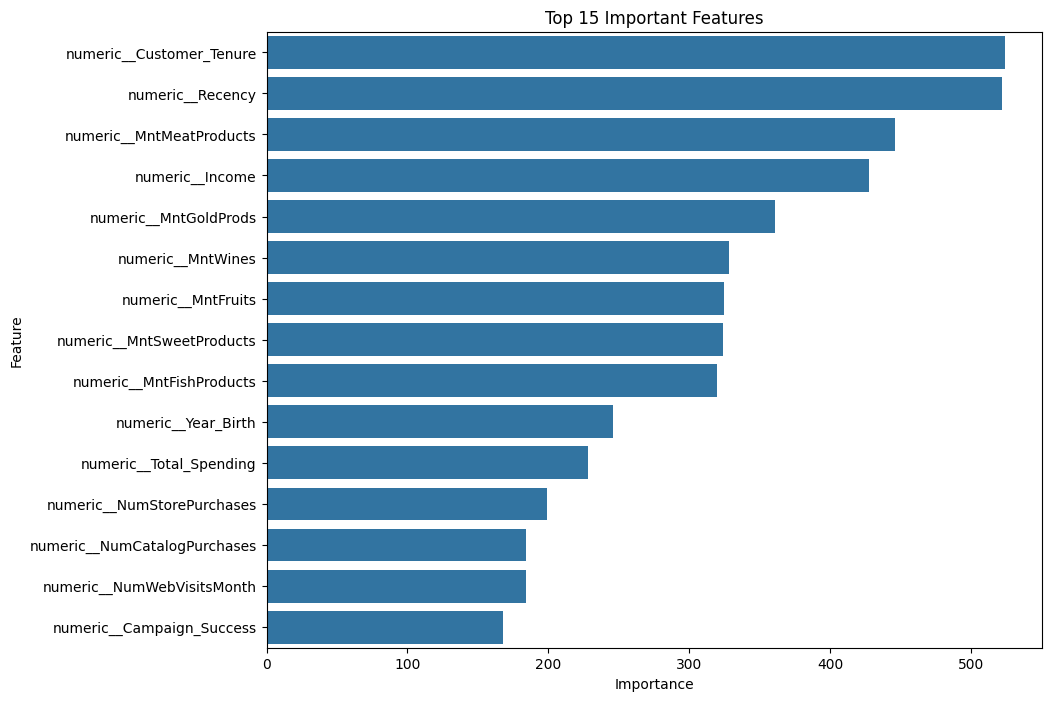

In [39]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance_df.head(15),
    x='Importance',
    y='Feature'
)

plt.title('Top 15 Important Features')
plt.show()

In [40]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_model = Pipeline([
    ('preprocessor', preprocessor),

    ('classifier',
     StackingClassifier(
         estimators=[
             ('rf', RandomForestClassifier(
                 n_estimators=200,
                 random_state=42
             )),
             ('gb', GradientBoostingClassifier(
                 random_state=42
             )),
             ('xgb', XGBClassifier(
                 random_state=42
             ))
         ],

         final_estimator=LogisticRegression()
     ))
])

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)

evaluate_model(
    'Stacking',
    y_test,
    y_pred_stack
)

In [41]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df.sort_values(
    'F1 Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
10,Stacking,0.904018,0.852941,0.432836,0.574257
9,LightGBM,0.890625,0.714286,0.447761,0.550459
8,XGBoost,0.892857,0.743590,0.432836,0.547170
7,Gradient Boosting,0.895089,0.777778,0.417910,0.543689
6,Gradient Boosting,0.895089,0.777778,0.417910,0.543689
0,Logistic Regression,0.886161,0.690476,0.432836,0.532110
3,Decision Tree,0.854911,0.517241,0.447761,0.480000
5,Random Forest,0.888393,0.793103,0.343284,0.479167
4,Random Forest,0.888393,0.793103,0.343284,0.479167
1,KNN,0.872768,0.625000,0.373134,0.467290


In [42]:
cluster_features = [
    'Income',
    'Age',
    'Children',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'Customer_Tenure'
]

cluster_df = df[cluster_features]

cluster_df.head()

,Income,Age,Children,Recency,Total_Spending,Total_Purchases,Customer_Tenure
0,58138.0,69,0,58,1617,22,663
1,46344.0,72,2,38,27,4,113
2,71613.0,61,0,26,776,20,312
3,26646.0,42,1,26,53,6,139
4,58293.0,45,1,94,422,14,161


In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

In [44]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)

    wcss.append(kmeans.inertia_)

In [45]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)

    wcss.append(kmeans.inertia_)

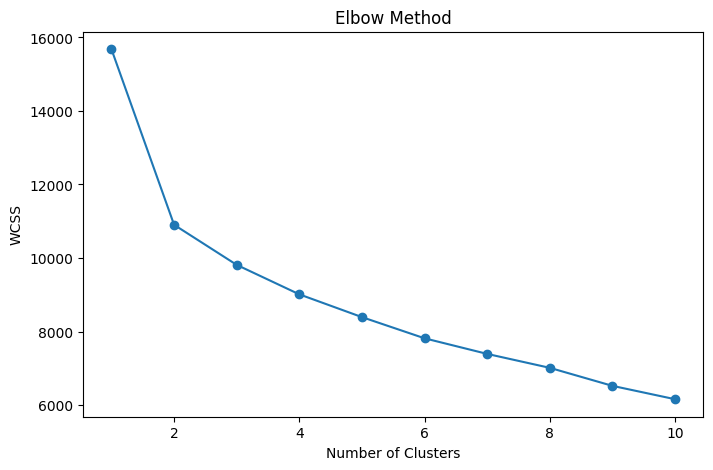

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')

plt.show()

In [47]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(cluster_scaled)

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    print(f"K={k}: {score:.4f}")

K=2: 0.2847
K=3: 0.2016
K=4: 0.1707
K=5: 0.1718
K=6: 0.1637
K=7: 0.1717
K=8: 0.1659
K=9: 0.1643
K=10: 0.1680


In [49]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(cluster_scaled)

In [50]:
df['KMeans_Cluster'].value_counts()

KMeans_Cluster
0    1267
1     973
Name: count, dtype: int64

In [51]:
cluster_profile = df.groupby(
    'KMeans_Cluster'
)[cluster_features].mean().round(2)

cluster_profile

,Income,Age,Children,Recency,Total_Spending,Total_Purchases,Customer_Tenure
KMeans_Cluster,,,,,,,
0,37616.07,55.48,1.27,48.92,158.37,7.26,333.15
1,71278.01,59.43,0.54,49.36,1188.42,19.41,380.18


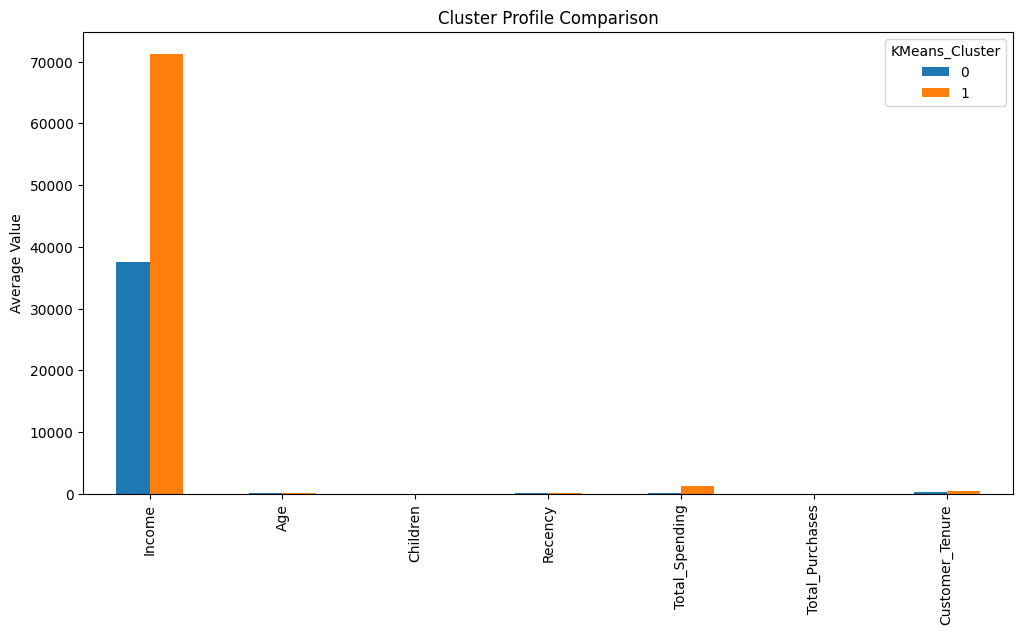

In [52]:
cluster_profile.T.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Cluster Profile Comparison")
plt.ylabel("Average Value")
plt.show()

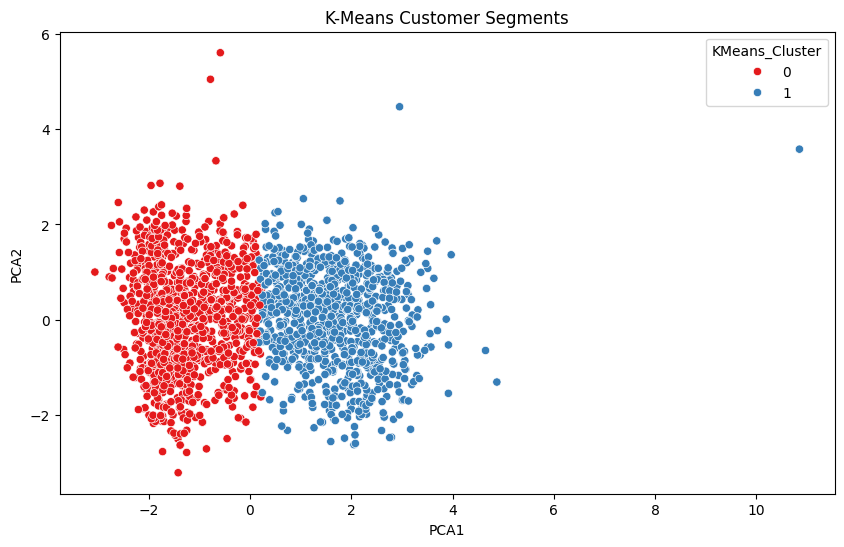

In [53]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(cluster_scaled)

df['PCA1'] = cluster_pca[:,0]
df['PCA2'] = cluster_pca[:,1]

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='KMeans_Cluster',
    palette='Set1'
)

plt.title('K-Means Customer Segments')
plt.show()

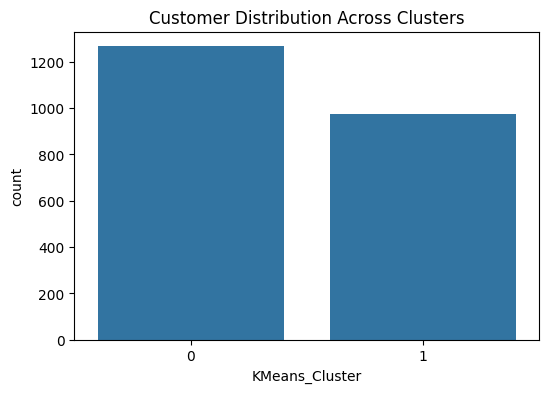

In [54]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='KMeans_Cluster'
)

plt.title('Customer Distribution Across Clusters')
plt.show()

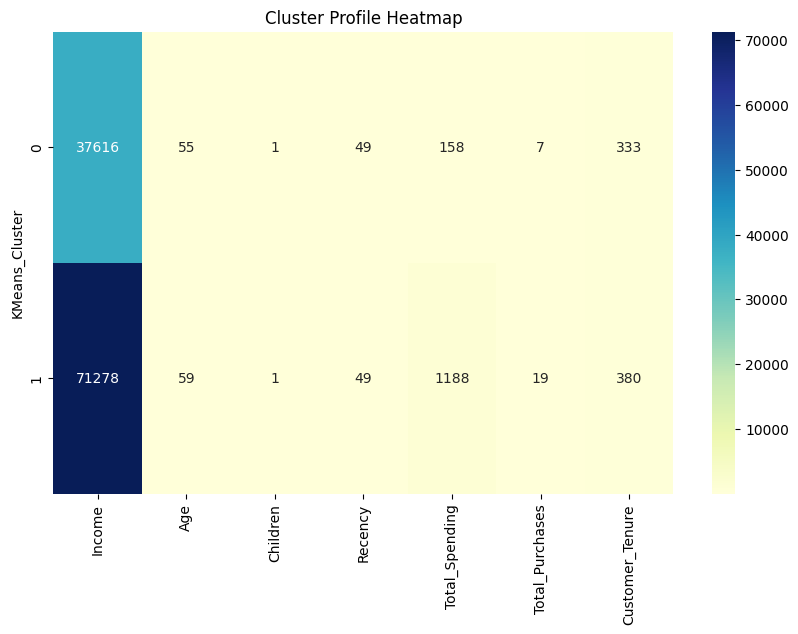

In [55]:
plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap='YlGnBu',
    fmt='.0f'
)

plt.title('Cluster Profile Heatmap')
plt.show()

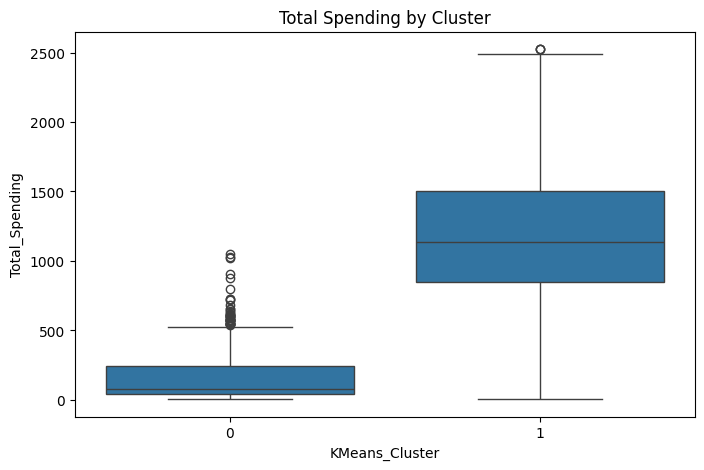

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='KMeans_Cluster',
    y='Total_Spending'
)

plt.title('Total Spending by Cluster')
plt.show()

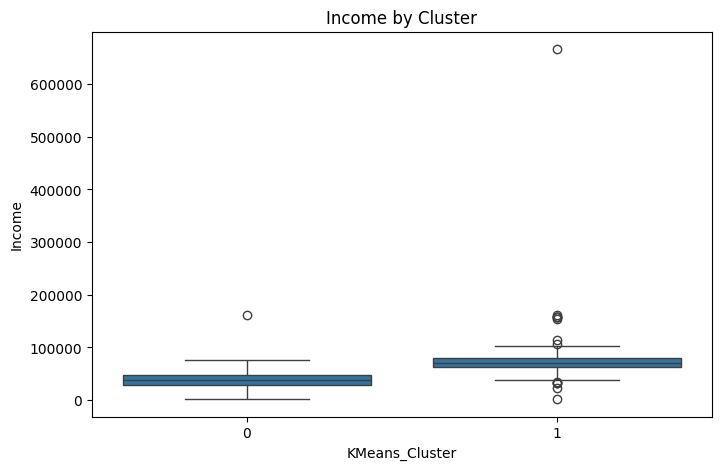

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='KMeans_Cluster',
    y='Income'
)

plt.title('Income by Cluster')
plt.show()

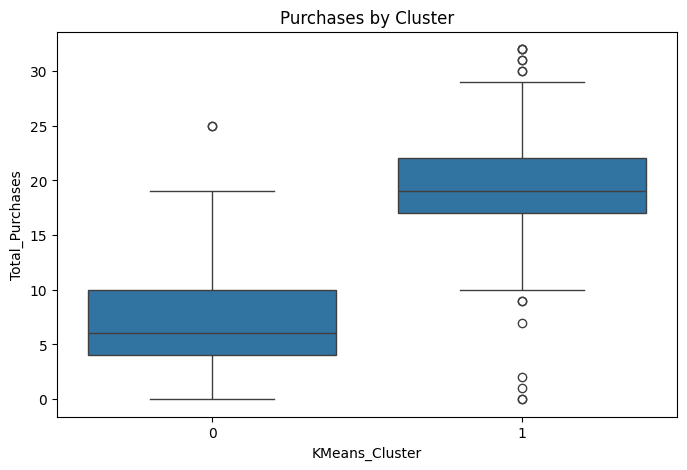

In [58]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='KMeans_Cluster',
    y='Total_Purchases'
)

plt.title('Purchases by Cluster')
plt.show()

In [59]:
cluster_response = (
    df.groupby('KMeans_Cluster')['Response']
    .mean()
    .reset_index()
)

cluster_response

,KMeans_Cluster,Response
0,0,0.094712
1,1,0.219938


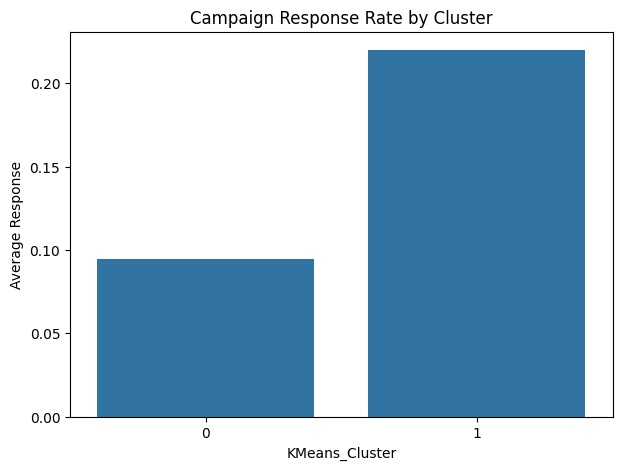

In [60]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=cluster_response,
    x='KMeans_Cluster',
    y='Response'
)

plt.title('Campaign Response Rate by Cluster')
plt.ylabel('Average Response')

plt.show()

In [61]:
cluster_response

,KMeans_Cluster,Response
0,0,0.094712
1,1,0.219938


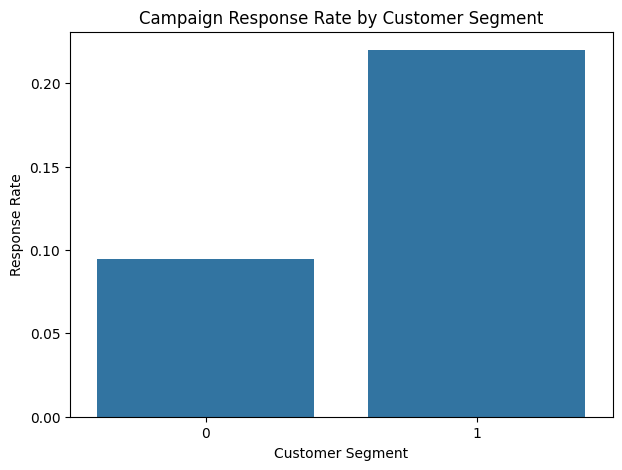

In [62]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=cluster_response,
    x='KMeans_Cluster',
    y='Response'
)

plt.title('Campaign Response Rate by Customer Segment')
plt.ylabel('Response Rate')
plt.xlabel('Customer Segment')

plt.show()

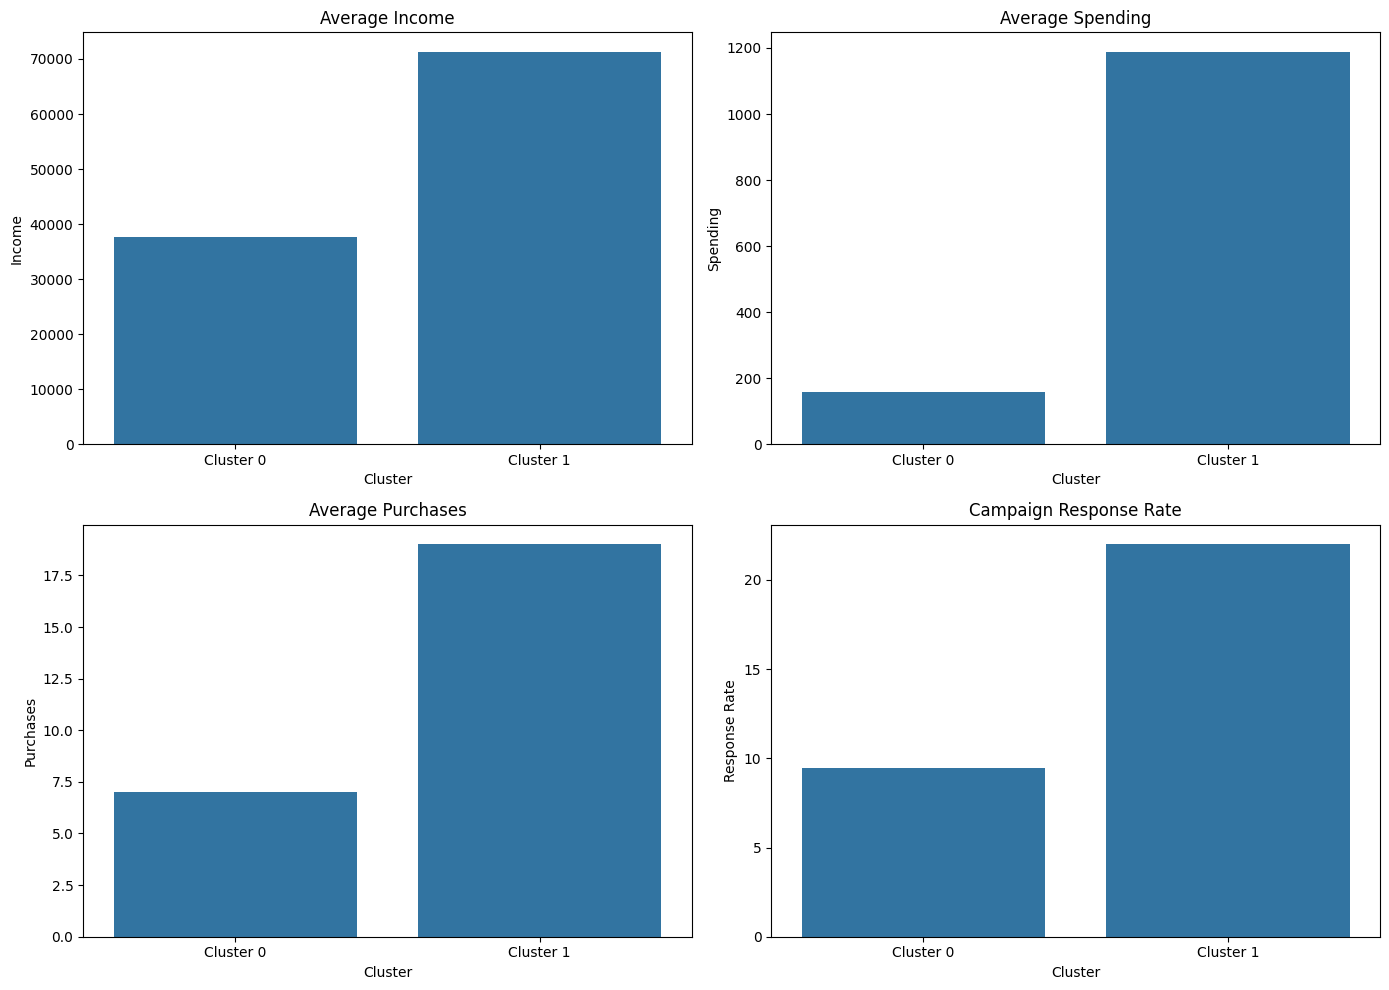

In [63]:
summary = pd.DataFrame({
    'Cluster':['Cluster 0','Cluster 1'],
    'Income':[37616,71278],
    'Spending':[158,1188],
    'Purchases':[7,19],
    'Response Rate':[9.47,21.99]
})

fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.barplot(data=summary,x='Cluster',y='Income',ax=axes[0,0])
axes[0,0].set_title('Average Income')

sns.barplot(data=summary,x='Cluster',y='Spending',ax=axes[0,1])
axes[0,1].set_title('Average Spending')

sns.barplot(data=summary,x='Cluster',y='Purchases',ax=axes[1,0])
axes[1,0].set_title('Average Purchases')

sns.barplot(data=summary,x='Cluster',y='Response Rate',ax=axes[1,1])
axes[1,1].set_title('Campaign Response Rate')

plt.tight_layout()
plt.show()

In [66]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.2,
    min_samples=10
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(cluster_scaled)

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 2    1110
 1     431
 0     393
-1     215
 3      91
Name: count, dtype: int64


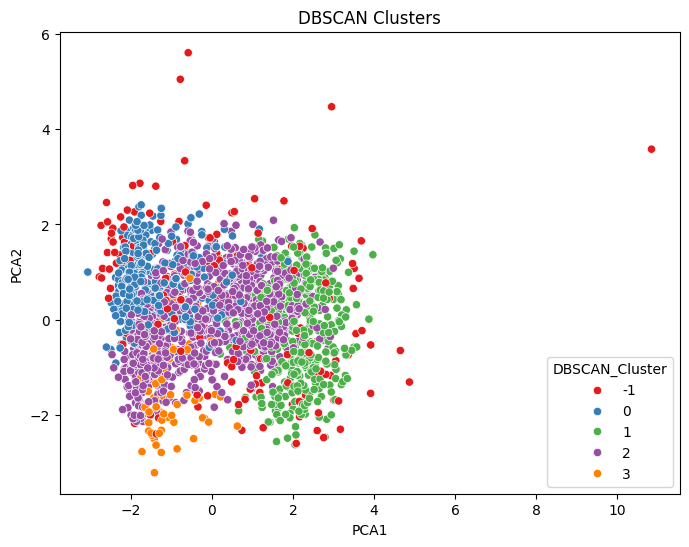

In [67]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='PCA1',
    y='PCA2',
    hue='DBSCAN_Cluster',
    palette='Set1'
)

plt.title('DBSCAN Clusters')
plt.show()

In [68]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 2    1110
 1     431
 0     393
-1     215
 3      91
Name: count, dtype: int64